<h1 style="font-size:28px;">01 - Data Understanding</h1>

<h3 style="font-size:20px;">Objective</h3>

<p style="font-size:15px;">
Understand the dataset structure, variable distributions, identify data issues, and analyze relationships between variables to support both data cleaning and model interpretation.
</p>

<blockquote style="font-size:14px;">
Principle: Do not process the data before understanding the data.
</blockquote>

<h3 style="font-size:20px;">Dataset</h3>

<p style="font-size:15px;">
English Premier League matches (2000–2018) — 6,840 matches
</p>

<h3 style="font-size:20px;">Problem Statement</h3>

<ul style="font-size:15px;">
<li>Classification: Whether the home team wins (<code>H</code>) or not (<code>NH</code>)</li>
</ul>

##  1. Import Libaries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

print('Libraries imported successfully.')

Libraries imported successfully.


## 2. Load data and view sample

In [ ]:
df = pd.read_csv(r"..data\raw_data", index_col=0)
print(f'Shape: {df.shape}')
print(f'Period: {df["Date"].iloc[0]} → {df["Date"].iloc[-1]}')
df.head(10)

Shape: (6840, 39)
Period: 19/08/00 → 13/05/18


,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTGS,ATGS,HTGC,ATGC,...,HTLossStreak3,HTLossStreak5,ATWinStreak3,ATWinStreak5,ATLossStreak3,ATLossStreak5,HTGD,ATGD,DiffPts,DiffFormPts
0,19/08/00,Charlton,Man City,4,0,H,0,0,0,0,...,0,0,0,0,0,0,0.0,0.0,0.0,0.0
1,19/08/00,Chelsea,West Ham,4,2,H,0,0,0,0,...,0,0,0,0,0,0,0.0,0.0,0.0,0.0
2,19/08/00,Coventry,Middlesbrough,1,3,NH,0,0,0,0,...,0,0,0,0,0,0,0.0,0.0,0.0,0.0
3,19/08/00,Derby,Southampton,2,2,NH,0,0,0,0,...,0,0,0,0,0,0,0.0,0.0,0.0,0.0
4,19/08/00,Leeds,Everton,2,0,H,0,0,0,0,...,0,0,0,0,0,0,0.0,0.0,0.0,0.0
5,19/08/00,Leicester,Aston Villa,0,0,NH,0,0,0,0,...,0,0,0,0,0,0,0.0,0.0,0.0,0.0
6,19/08/00,Liverpool,Bradford,1,0,H,0,0,0,0,...,0,0,0,0,0,0,0.0,0.0,0.0,0.0
7,19/08/00,Sunderland,Arsenal,1,0,H,0,0,0,0,...,0,0,0,0,0,0,0.0,0.0,0.0,0.0
8,19/08/00,Tottenham,Ipswich,3,1,H,0,0,0,0,...,0,0,0,0,0,0,0.0,0.0,0.0,0.0
9,20/08/00,Man United,Newcastle,2,0,H,0,0,0,0,...,0,0,0,0,0,0,0.0,0.0,0.0,0.0


<p style="font-size:15px;">

<b>Comments:</b>

<ul>
<li>Dataset contains <b>6,840 matches</b> and <b>39 columns</b>, covering seasons from 2000/01 to 2017/18.</li>

<li>Each row represents a single match with cumulative statistics of both teams <b>before the match</b>, meaning there is no future information leakage.</li>

<li>The columns <code>HM1–HM5</code> and <code>AM1–AM5</code> contain categorical match results (W/D/L/M) and will need to be encoded during the Cleaning step.</li>
</ul>

</p>

## 3. Related Information

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6840 entries, 0 to 6839
Data columns (total 39 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           6840 non-null   str    
 1   HomeTeam       6840 non-null   str    
 2   AwayTeam       6840 non-null   str    
 3   FTHG           6840 non-null   int64  
 4   FTAG           6840 non-null   int64  
 5   FTR            6840 non-null   str    
 6   HTGS           6840 non-null   int64  
 7   ATGS           6840 non-null   int64  
 8   HTGC           6840 non-null   int64  
 9   ATGC           6840 non-null   int64  
 10  HTP            6840 non-null   float64
 11  ATP            6840 non-null   float64
 12  HM1            6840 non-null   str    
 13  HM2            6840 non-null   str    
 14  HM3            6840 non-null   str    
 15  HM4            6840 non-null   str    
 16  HM5            6840 non-null   str    
 17  AM1            6840 non-null   str    
 18  AM2            6840

<p style="font-size:15px;">

<b>Comments:</b>

<ul>
<li>Numerical columns (<code>float64</code>, <code>int64</code>) are stored in appropriate data types.</li>

<li><code>FTR</code>, <code>HM1–HM5</code>, <code>AM1–AM5</code>, <code>HTFormPtsStr</code>, <code>ATFormPtsStr</code>, <code>HomeTeam</code>, <code>AwayTeam</code>, and <code>Date</code> are stored as <code>object</code> type and will require preprocessing during the Cleaning step.</li>

<li><code>MW</code> is stored as <code>float</code>, which is acceptable due to the match week calculation method.</li>
</ul>

</p>

## 4. Descriptive statistics

In [ ]:
df.describe()

,count,mean,std,min,25%,50%,75%,max
FTHG,6840.0,1.527485,1.297913,0.000000,1.000000,1.000000,2.000000,9.000000
FTAG,6840.0,1.130263,1.124566,0.000000,0.000000,1.000000,2.000000,7.000000
HTGS,6840.0,24.416667,17.178524,0.000000,11.000000,23.000000,35.000000,102.000000
ATGS,6840.0,24.514327,17.136894,0.000000,11.000000,23.000000,35.000000,105.000000
HTGC,6840.0,24.497807,16.401571,0.000000,11.000000,23.000000,36.000000,85.000000
ATGC,6840.0,24.347515,16.341557,0.000000,11.000000,23.000000,36.000000,82.000000
HTP,6840.0,1.209014,0.530186,0.000000,0.888889,1.172414,1.555556,2.736842
ATP,6840.0,1.226768,0.523176,0.000000,0.906250,1.192308,1.562500,2.761905
MW,6840.0,19.500000,10.966658,1.000000,10.000000,19.500000,29.000000,38.000000
HTFormPts,6840.0,6.242690,3.582486,0.000000,4.000000,6.000000,9.000000,15.000000


<p style="font-size:15px;">

<b>Comments:</b>

<ul>
<li><code>FTHG</code> (full-time home goals) has an average of approximately <b>1.53</b>, while <code>FTAG</code> averages around <b>1.13</b>, indicating a clear <b>home advantage</b>.</li>

<li><code>HTP</code> and <code>ATP</code> show distributions close to normal, reflecting variation in team strength across the league.</li>

<li><code>DiffPts</code> and <code>HTGD</code> have minimum and maximum values relatively symmetric around 0, suggesting the dataset is reasonably balanced in terms of team strength differences.</li>
</ul>

</p>

## 5. Check for Missing Values

In [10]:
missing = df.isnull().sum()

print('Missing values per column:')
print(missing[missing > 0])

print(f'\nTotal missing values (NaN): {missing.sum()}')

# Check for 'M' values in match history columns (special missing values)
result_cols = ['HM1', 'HM2', 'HM3', 'HM4', 'HM5',
               'AM1', 'AM2', 'AM3', 'AM4', 'AM5']

print('\nUnique values in match history columns:')

for col in result_cols:
    print(f'  {col}: {sorted(df[col].unique())}')

m_total = (df[result_cols] == 'M').sum().sum()

print(f'\nTotal number of cells with value M (insufficient match history): {m_total}')

Missing values per column:
Series([], dtype: int64)

Total missing values (NaN): 0

Unique values in match history columns:
  HM1: ['D', 'L', 'M', 'W']
  HM2: ['D', 'L', 'M', 'W']
  HM3: ['D', 'L', 'M', 'W']
  HM4: ['D', 'L', 'M', 'W']
  HM5: ['D', 'L', 'M', 'W']
  AM1: ['D', 'L', 'M', 'W']
  AM2: ['D', 'L', 'M', 'W']
  AM3: ['D', 'L', 'M', 'W']
  AM4: ['D', 'L', 'M', 'W']
  AM5: ['D', 'L', 'M', 'W']

Total number of cells with value M (insufficient match history): 5400


<p style="font-size:15px;">

<b>Comments:</b>

<ul>
<li>There are no actual <code>NaN</code> values in the dataset.</li>

<li>The value <code>'M'</code> in <code>HM1–HM5</code> and <code>AM1–AM5</code> represents <b>structured missing data</b>. It appears in early-season matches when teams do not yet have enough historical match records. This is not a data error but a valid indication of unavailable previous match information.</li>

<li><code>HM5</code> and <code>AM5</code> contain the highest number of <code>'M'</code> values because teams need to have played at least 5 matches in the season before these fields can be fully populated.</li>
</ul>

</p>

## 6. Check for duplicate data

In [11]:
duplicates = df.duplicated().sum()
print(f'Number of Duplicates: {duplicates}')

Number of Duplicates: 0


<p style="font-size:15px;">

<b>Comments:</b>

<ul>
<li>The dataset does not contain duplicate rows, so no duplicate removal is required during the Cleaning step.</li>
</ul>

</p>

## 7. Univariate analysis

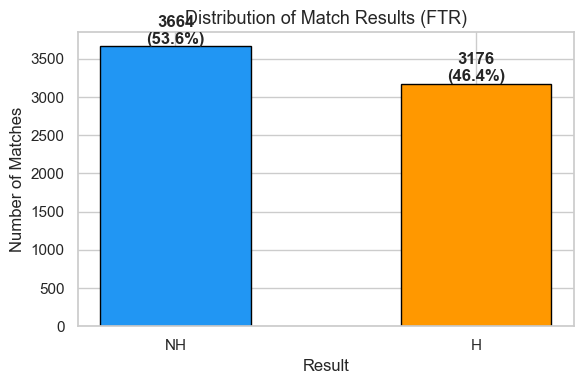

In [12]:
fig, ax = plt.subplots(figsize=(6, 4))

ftr_counts = df['FTR'].value_counts()

ax.bar(
    ftr_counts.index,
    ftr_counts.values,
    color=['#2196F3', '#FF9800'],
    edgecolor='black',
    width=0.5
)

ax.set_title('Distribution of Match Results (FTR)', fontsize=13)
ax.set_xlabel('Result')
ax.set_ylabel('Number of Matches')

for i, (k, v) in enumerate(ftr_counts.items()):
    ax.text(
        i,
        v + 30,
        f'{v}\n({v/len(df)*100:.1f}%)',
        ha='center',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

<p style="font-size:15px;">

<b>Comments:</b>

<ul>
<li>Home Win = 3,176 matches (46.4%) while Not Home Win = 3,664 matches (53.6%), indicating a relatively balanced class distribution.</li>

<li>The dataset does not show significant class imbalance, so no additional imbalance handling techniques are required at this stage.</li>

## 8. Distribution of important variables (Univariate)

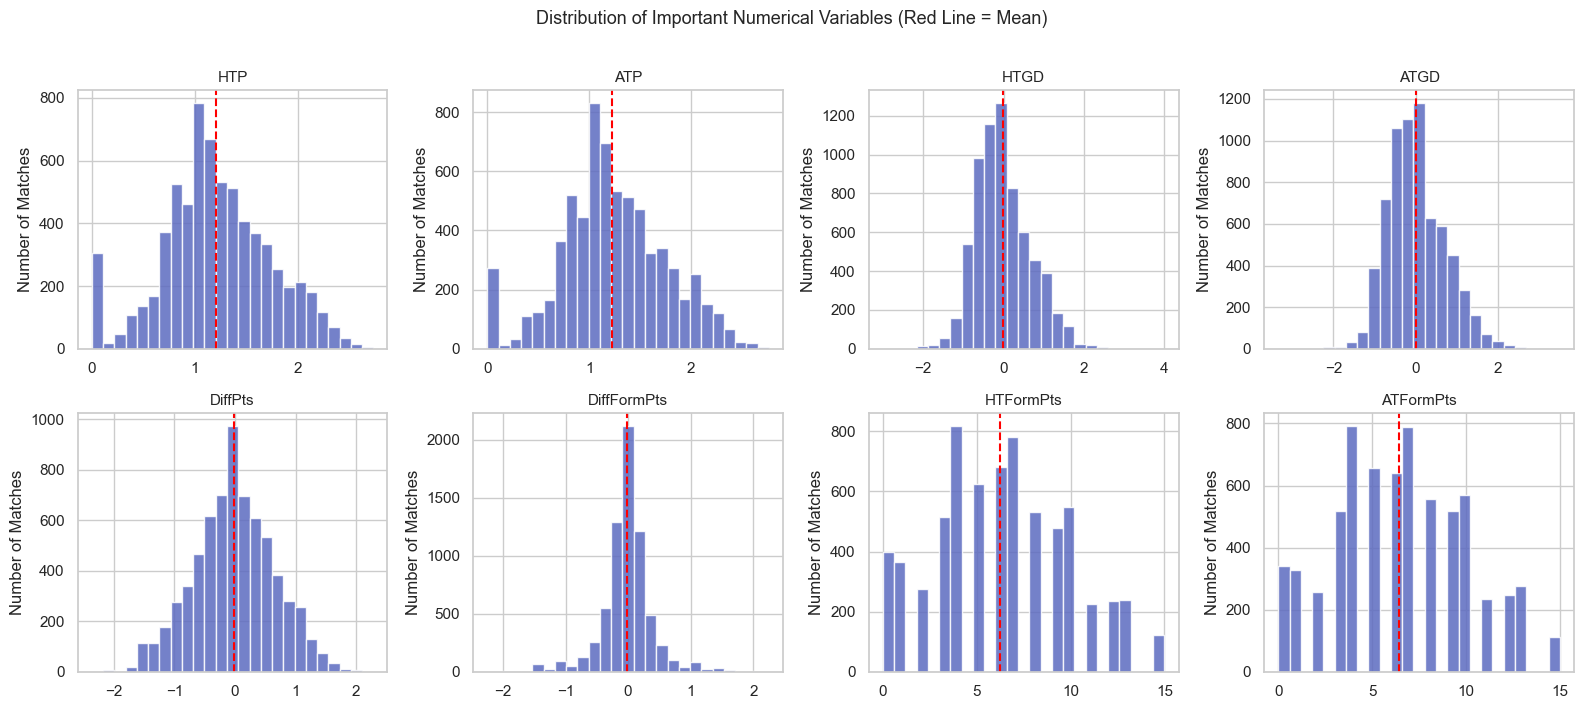

In [13]:
num_cols = ['HTP', 'ATP', 'HTGD', 'ATGD',
            'DiffPts', 'DiffFormPts',
            'HTFormPts', 'ATFormPts']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(
        df[col],
        bins=25,
        color='#5C6BC0',
        edgecolor='white',
        alpha=0.85
    )

    axes[i].axvline(
        df[col].mean(),
        color='red',
        linestyle='--',
        lw=1.5
    )

    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel('Number of Matches')

plt.suptitle(
    'Distribution of Important Numerical Variables (Red Line = Mean)',
    fontsize=13,
    y=1.01
)

plt.tight_layout()
plt.show()

<p style="font-size:15px;">

<b>Comments:</b>

<ul>
<li><code>HTP</code> and <code>ATP</code> show distributions close to normal, with most values concentrated around 30–50 points.</li>

<li><code>HTGD</code>, <code>ATGD</code>, <code>DiffPts</code>, and <code>DiffFormPts</code> are relatively symmetric around 0, indicating that the dataset is not heavily biased toward stronger or weaker teams.</li>

<li><code>HTFormPts</code> and <code>ATFormPts</code> are mainly concentrated between 3–9 points, representing approximately 1–3 wins within the last 5 matches.</li>
</ul>

</p>

## 9. Check Outliers

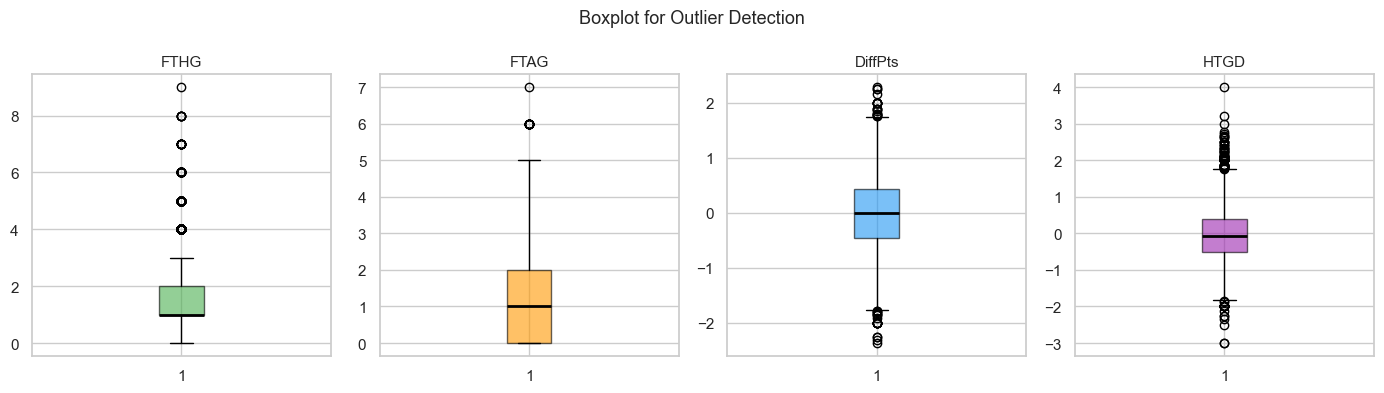

Number of matches with FTHG >= 5 goals: 175 (2.6%)


In [14]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))

box_cols = ['FTHG', 'FTAG', 'DiffPts', 'HTGD']
colors = ['#4CAF50', '#FF9800', '#2196F3', '#9C27B0']

for i, (col, color) in enumerate(zip(box_cols, colors)):
    axes[i].boxplot(
        df[col],
        patch_artist=True,
        boxprops=dict(facecolor=color, alpha=0.6),
        medianprops=dict(color='black', lw=2)
    )

    axes[i].set_title(col, fontsize=11)

plt.suptitle('Boxplot for Outlier Detection', fontsize=13)

plt.tight_layout()
plt.show()

print(
    f'Number of matches with FTHG >= 5 goals: '
    f'{(df["FTHG"] >= 5).sum()} '
    f'({(df["FTHG"] >= 5).mean()*100:.1f}%)'
)

<p style="font-size:15px;">

<b>Comments:</b>

<ul>
<li>Outliers in <code>FTHG</code> and <code>FTAG</code> represent real high-scoring matches and should be <b>retained</b>, as they are valid observations rather than data errors.</li>
</ul>

</p>

## 10. Bivariate Analysis — Distribution based on outcomes (FTR)

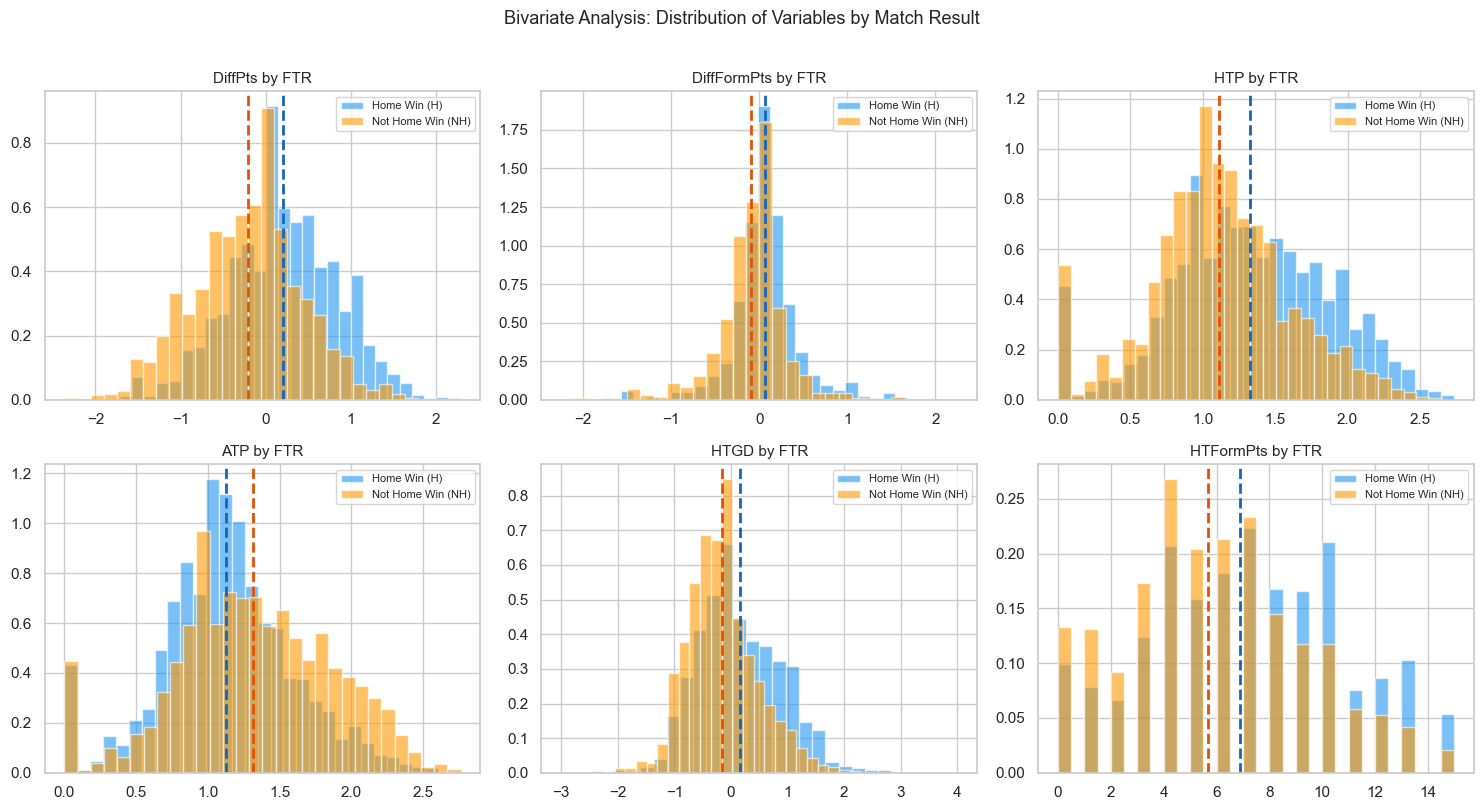

In [15]:
compare_cols = ['DiffPts', 'DiffFormPts', 'HTP',
                'ATP', 'HTGD', 'HTFormPts']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(compare_cols):

    h_vals = df[df['FTR'] == 'H'][col]
    nh_vals = df[df['FTR'] == 'NH'][col]

    axes[i].hist(
        h_vals,
        bins=30,
        alpha=0.6,
        label='Home Win (H)',
        color='#2196F3',
        density=True
    )

    axes[i].hist(
        nh_vals,
        bins=30,
        alpha=0.6,
        label='Not Home Win (NH)',
        color='#FF9800',
        density=True
    )

    axes[i].axvline(
        h_vals.mean(),
        color='#1565C0',
        linestyle='--',
        lw=2
    )

    axes[i].axvline(
        nh_vals.mean(),
        color='#E65100',
        linestyle='--',
        lw=2
    )

    axes[i].set_title(f'{col} by FTR', fontsize=11)
    axes[i].legend(fontsize=8)

plt.suptitle(
    'Bivariate Analysis: Distribution of Variables by Match Result',
    fontsize=13,
    y=1.01
)

plt.tight_layout()
plt.show()

<p style="font-size:15px;">

<b>Comments:</b>

<ul>
<li><code>DiffPts</code>: When the home team is stronger than the away team (<code>DiffPts &gt; 0</code>), the probability of a Home Win increases significantly, making this one of the most important features.</li>

<li><code>DiffFormPts</code> and <code>HTFormPts</code>: Better recent form is also associated with a higher chance of winning.</li>

<li><code>ATP</code>: Higher accumulated points for the away team tend to reduce the probability of a Home Win, indicating that strong away teams are more difficult to defeat.</li>
</ul>

</p>

## 11. Bivariate Analysis — Boxplot by FTR

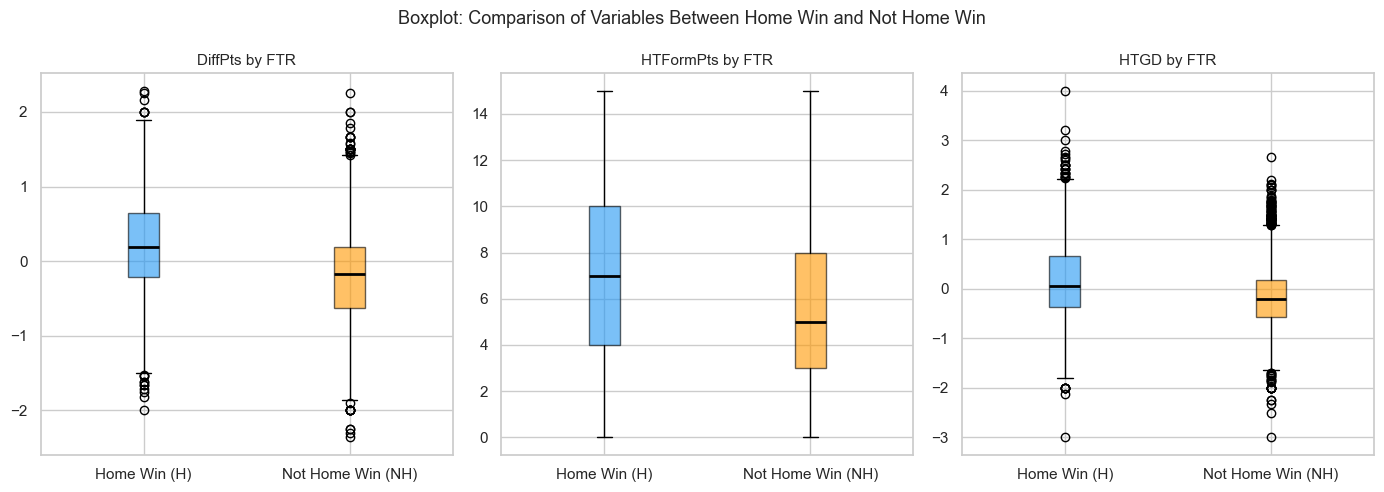

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

box_features = ['DiffPts', 'HTFormPts', 'HTGD']

for i, col in enumerate(box_features):

    data_h = df[df['FTR'] == 'H'][col]
    data_nh = df[df['FTR'] == 'NH'][col]

    bp = axes[i].boxplot(
        [data_h, data_nh],
        labels=['Home Win (H)', 'Not Home Win (NH)'],
        patch_artist=True,
        medianprops=dict(color='black', lw=2)
    )

    bp['boxes'][0].set_facecolor('#2196F3')
    bp['boxes'][0].set_alpha(0.6)

    bp['boxes'][1].set_facecolor('#FF9800')
    bp['boxes'][1].set_alpha(0.6)

    axes[i].set_title(f'{col} by FTR', fontsize=11)

plt.suptitle(
    'Boxplot: Comparison of Variables Between Home Win and Not Home Win',
    fontsize=13
)

plt.tight_layout()
plt.show()

<p style="font-size:15px;">

<b>Comments:</b>

<ul>
<li>The median values of <code>DiffPts</code>, <code>HTFormPts</code>, and <code>HTGD</code> are noticeably higher in Home Win matches compared to Not Home Win matches, confirming that these variables have strong discriminative power.</li>

<li>The clear median differences suggest that the model will likely be able to learn meaningful patterns from these features.</li>
</ul>

</p>

## 12. Correlation Matrix

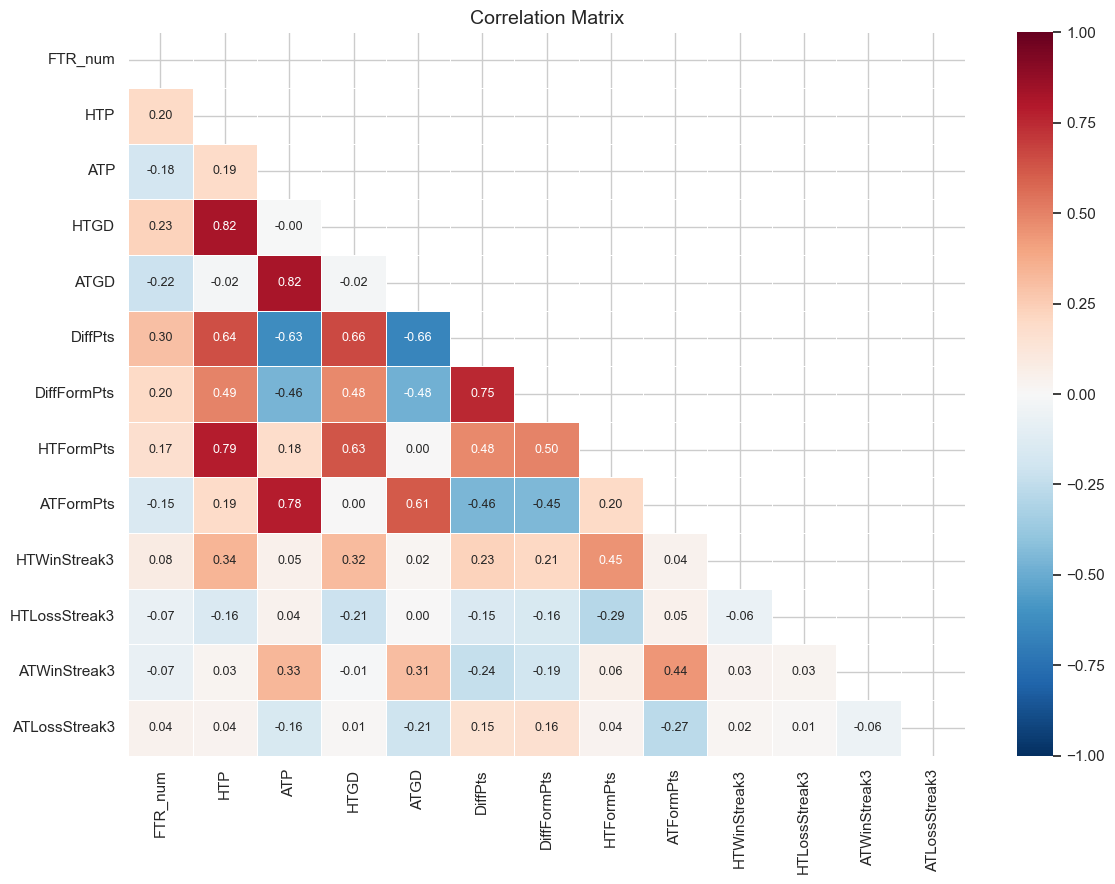

In [17]:
df_corr = df.copy()

df_corr['FTR_num'] = df_corr['FTR'].map({'H': 1, 'NH': 0})

corr_cols = [
    'FTR_num', 'HTP', 'ATP', 'HTGD', 'ATGD',
    'DiffPts', 'DiffFormPts', 'HTFormPts', 'ATFormPts',
    'HTWinStreak3', 'HTLossStreak3',
    'ATWinStreak3', 'ATLossStreak3'
]

corr_matrix = df_corr[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    mask=mask,
    ax=ax,
    linewidths=0.5,
    annot_kws={'size': 9}
)

ax.set_title('Correlation Matrix', fontsize=14)

plt.tight_layout()
plt.show()

<p style="font-size:15px;">

<b>Comments from the Correlation Matrix:</b>

<ul>
<li><b>Regarding the target variable <code>FTR_num</code>:</b></li>

<ul>
<li><code>DiffPts</code> shows the strongest positive correlation (~0.25), indicating that point difference is one of the best predictors of match outcome.</li>

<li><code>DiffFormPts</code>, <code>HTFormPts</code>, and <code>HTWinStreak3</code> have positive correlations, suggesting that teams with better recent form are more likely to win at home.</li>

<li><code>ATFormPts</code> and <code>ATWinStreak3</code> have negative correlations, meaning stronger away teams reduce the probability of a home win.</li>
</ul>

<li><b>Potential Multicollinearity:</b></li>

<ul>
<li><code>HTP</code> and <code>HTGD</code> have a high correlation (~0.8+), indicating overlapping information.</li>

<li><code>HTFormPts</code> and <code>HTWinStreak3</code> are also highly correlated, as both reflect strong recent team performance.</li>

<li>This does not create a major issue for Logistic Regression, but it should be considered when interpreting model coefficients.</li>
</ul>

</ul>

</p>

## 13. Correlation of variables with FTR — Bar chart

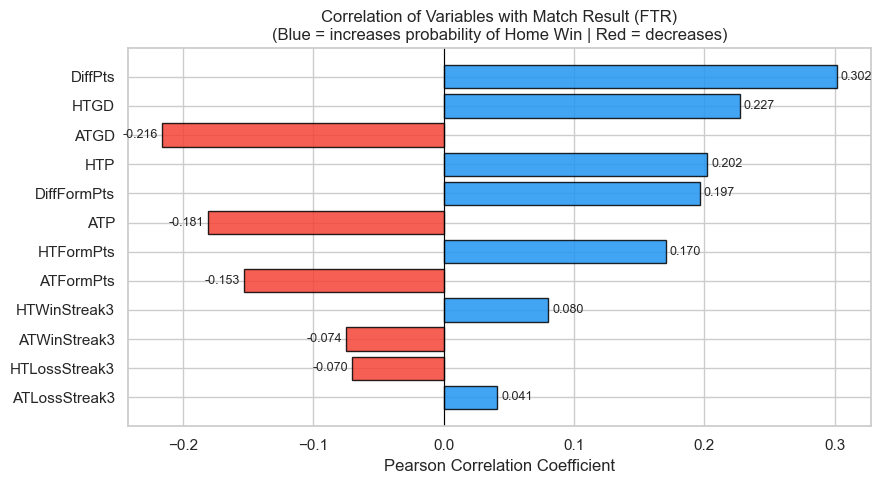

In [18]:
corr_with_ftr = (
    corr_matrix['FTR_num']
    .drop('FTR_num')
    .sort_values(key=abs, ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 5))

colors = [
    '#2196F3' if v > 0 else '#F44336'
    for v in corr_with_ftr
]

ax.barh(
    corr_with_ftr.index[::-1],
    corr_with_ftr.values[::-1],
    color=colors[::-1],
    edgecolor='black',
    alpha=0.85
)

ax.axvline(0, color='black', lw=0.8)

ax.set_title(
    'Correlation of Variables with Match Result (FTR)\n'
    '(Blue = increases probability of Home Win | Red = decreases)',
    fontsize=12
)

ax.set_xlabel('Pearson Correlation Coefficient')

for i, (val, name) in enumerate(
    zip(corr_with_ftr.values[::-1], corr_with_ftr.index[::-1])
):
    ax.text(
        val + 0.003 if val >= 0 else val - 0.003,
        i,
        f'{val:.3f}',
        va='center',
        ha='left' if val >= 0 else 'right',
        fontsize=9
    )

plt.tight_layout()
plt.show()

<p style="font-size:15px;">

<b>Comments:</b>

<ul>
<li><code>DiffPts</code>, <code>HTWinStreak3</code>, and <code>DiffFormPts</code> are the three variables most strongly correlated with the Home Win outcome.</li>

<li>These features are expected to have relatively large coefficients in the Logistic Regression model.</li>
</ul>

</p>

## 14. Analysis by team

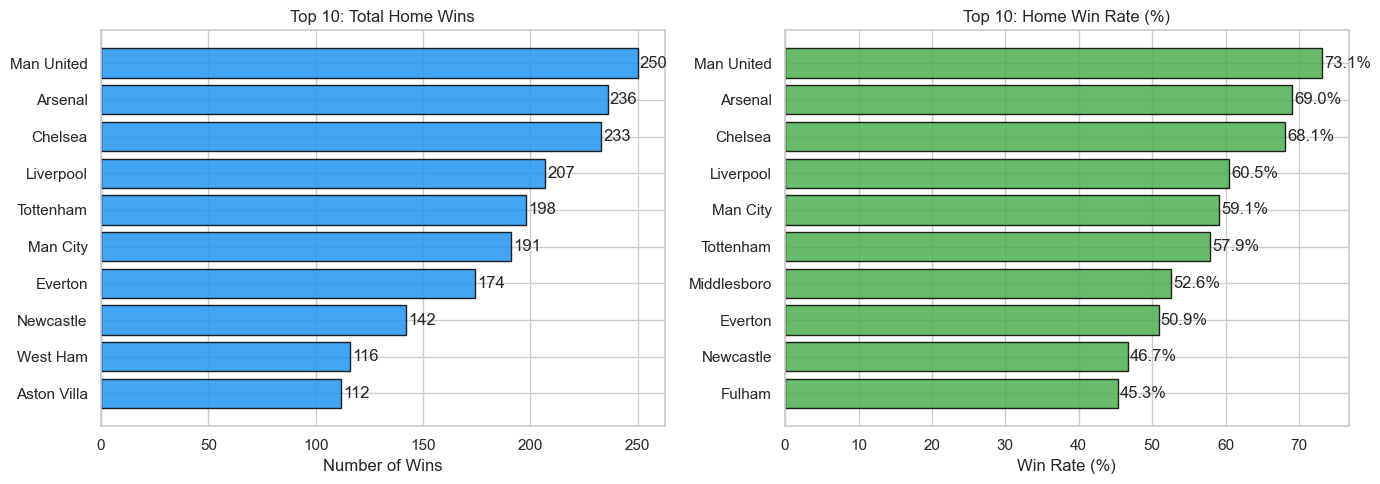

In [19]:
home_wins = (
    df[df['FTR'] == 'H']
    .groupby('HomeTeam')
    .size()
    .sort_values(ascending=False)
    .head(10)
)

home_rate = (
    df[df['FTR'] == 'H']
    .groupby('HomeTeam')
    .size()
    / df.groupby('HomeTeam').size() * 100
).sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars1 = axes[0].barh(
    home_wins.index[::-1],
    home_wins.values[::-1],
    color='#2196F3',
    edgecolor='black',
    alpha=0.85
)

axes[0].set_title('Top 10: Total Home Wins', fontsize=12)
axes[0].set_xlabel('Number of Wins')

for bar, val in zip(bars1, home_wins.values[::-1]):
    axes[0].text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height() / 2,
        str(val),
        va='center'
    )

bars2 = axes[1].barh(
    home_rate.index[::-1],
    home_rate.values[::-1],
    color='#4CAF50',
    edgecolor='black',
    alpha=0.85
)

axes[1].set_title('Top 10: Home Win Rate (%)', fontsize=12)
axes[1].set_xlabel('Win Rate (%)')

for bar, val in zip(bars2, home_rate.values[::-1]):
    axes[1].text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.1f}%',
        va='center'
    )

plt.tight_layout()
plt.show()

<p style="font-size:15px;">

<b>Comments:</b>

<ul>
<li>Manchester United, Arsenal, and Chelsea recorded the highest number of home wins in the dataset.</li>

<li>The home win rates of strong teams (~60–70%) are significantly higher than the overall dataset average (~46%), indicating that <b>home advantage</b> is relative and strongly influenced by team quality.</li>
</ul>

</p>

## Conclusion — Data Understanding

<p style="font-size:15px;">

<table>
<thead>
<tr>
<th>Identified Issue</th>
<th>Details</th>
<th>Planned Handling</th>
</tr>
</thead>

<tbody>

<tr>
<td>Structured Missing Values (<code>'M'</code>)</td>
<td>Appears in <code>HM1–HM5</code> and <code>AM1–AM5</code> during early-season matches</td>
<td>Apply One-Hot Encoding and keep <code>'M'</code> as a separate category</td>
</tr>

<tr>
<td>Duplicate Rows</td>
<td>0 duplicate rows detected</td>
<td>No action required</td>
</tr>

<tr>
<td>Outliers in <code>FTHG</code>/<code>FTAG</code></td>
<td>High-scoring matches (≥5 goals)</td>
<td>Retain because they are valid observations</td>
</tr>

<tr>
<td>Multicollinearity</td>
<td><code>HTP</code> &amp; <code>HTGD</code>, <code>HTFormPts</code> &amp; <code>HTWinStreak3</code></td>
<td>Consider carefully when interpreting model coefficients</td>
</tr>

<tr>
<td>Variables to Remove</td>
<td><code>FTHG</code>, <code>FTAG</code>, <code>HTGS</code>, <code>ATGS</code>, <code>HTGC</code>, <code>ATGC</code>, <code>HM4</code>, <code>HM5</code>, <code>AM4</code>, <code>AM5</code>, etc.</td>
<td>Remove during the Cleaning step</td>
</tr>

<tr>
<td>Categorical Variables</td>
<td><code>HM1–HM3</code>, <code>AM1–AM3</code>, <code>FTR</code></td>
<td>Encode during the Cleaning step</td>
</tr>

<tr>
<td>Scaling by Match Week</td>
<td><code>HTP</code>, <code>ATP</code>, <code>HTGD</code>, <code>ATGD</code>, <code>DiffPts</code>, <code>DiffFormPts</code></td>
<td>Normalize by dividing by <code>MW</code> during Cleaning</td>
</tr>

</tbody>
</table>

<br>

<b>Conclusion:</b> The dataset is of good quality overall. <code>DiffPts</code>, <code>DiffFormPts</code>, and <code>HTWinStreak3</code> appear to be the most promising features for the Classification model.

</p>